In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT = "/content/drive/MyDrive/delivery_delay_project"
RAW     = f"{PROJECT}/data/raw"
PROC    = f"{PROJECT}/data/processed"

# Create processed folder if it doesn't exist
os.makedirs(PROC, exist_ok=True)

print("✅ Paths set!")

✅ Paths set!


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{RAW}/train.csv")

print(f"Shape     : {df.shape}")
print(f"Columns   : {list(df.columns)}")
print(f"Nulls     :\n{df.isnull().sum()}")
df.head(3)

Shape     : (45593, 20)
Columns   : ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']
Nulls     :
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries    

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26


In [ ]:
# Standardise column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Fix weather column (remove "conditions " prefix if present)
if 'weatherconditions' in df.columns:
    df.rename(columns={'weatherconditions': 'weather_conditions'}, inplace=True)

df['weather_conditions'] = df['weather_conditions'].str.replace("conditions ", "", regex=False).str.strip()

# Fix time_taken column (remove "(min) " prefix)
df['time_taken'] = df['time_taken(min)'].str.replace("(min) ", "", regex=False).astype(float)
df.drop(columns=['time_taken(min)'], inplace=True)

# Extract city from Delivery_person_ID
df['city_code'] = df['delivery_person_id'].str.split("RES").str[0]

print("✅ Columns cleaned!")
print(df.dtypes)

✅ Columns cleaned!
id                              object
delivery_person_id              object
delivery_person_age             object
delivery_person_ratings         object
restaurant_latitude            float64
restaurant_longitude           float64
delivery_location_latitude     float64
delivery_location_longitude    float64
order_date                      object
time_orderd                     object
time_order_picked               object
weather_conditions              object
road_traffic_density            object
vehicle_condition                int64
type_of_order                   object
type_of_vehicle                 object
multiple_deliveries             object
festival                        object
city                            object
time_taken                     float64
city_code                       object
dtype: object


In [ ]:
import math

# Haversine formula to calculate distance between 2 GPS points
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))

df['distance_km'] = df.apply(
    lambda r: haversine(r['restaurant_latitude'], r['restaurant_longitude'],
                        r['delivery_location_latitude'], r['delivery_location_longitude']),
    axis=1
)

# Time features
df['order_hour']   = pd.to_datetime(df['time_orderd'], errors='coerce').dt.hour
df['is_peak_hour'] = df['order_hour'].apply(
    lambda h: 1 if h in list(range(12,14)) + list(range(19,22)) else 0
)

# Rain flag from weather
df['rain_flag'] = df['weather_conditions'].str.lower().str.contains('rain').astype(int)

# Festival flag
df['festival_flag'] = (df['festival'].str.strip().str.lower() == 'yes').astype(int)

# Distance bucket
df['distance_bucket'] = pd.cut(df['distance_km'],
    bins=[0,3,6,10,20,100],
    labels=['very_short','short','medium','long','very_long']
)

print("✅ Features engineered!")
print(df[['distance_km','is_peak_hour','rain_flag','festival_flag']].head())

✅ Features engineered!
   distance_km  is_peak_hour  rain_flag  festival_flag
0     3.025149             0          0              0
1    20.183530             1          0              0
2     1.552758             0          0              0
3     7.790401             0          0              0
4     6.210138             1          0              0


/tmp/ipykernel_4103/2454595862.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_hour']   = pd.to_datetime(df['time_orderd'], errors='coerce').dt.hour


/tmp/ipykernel_4103/2037728682.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(['Normal', 'Festival'])


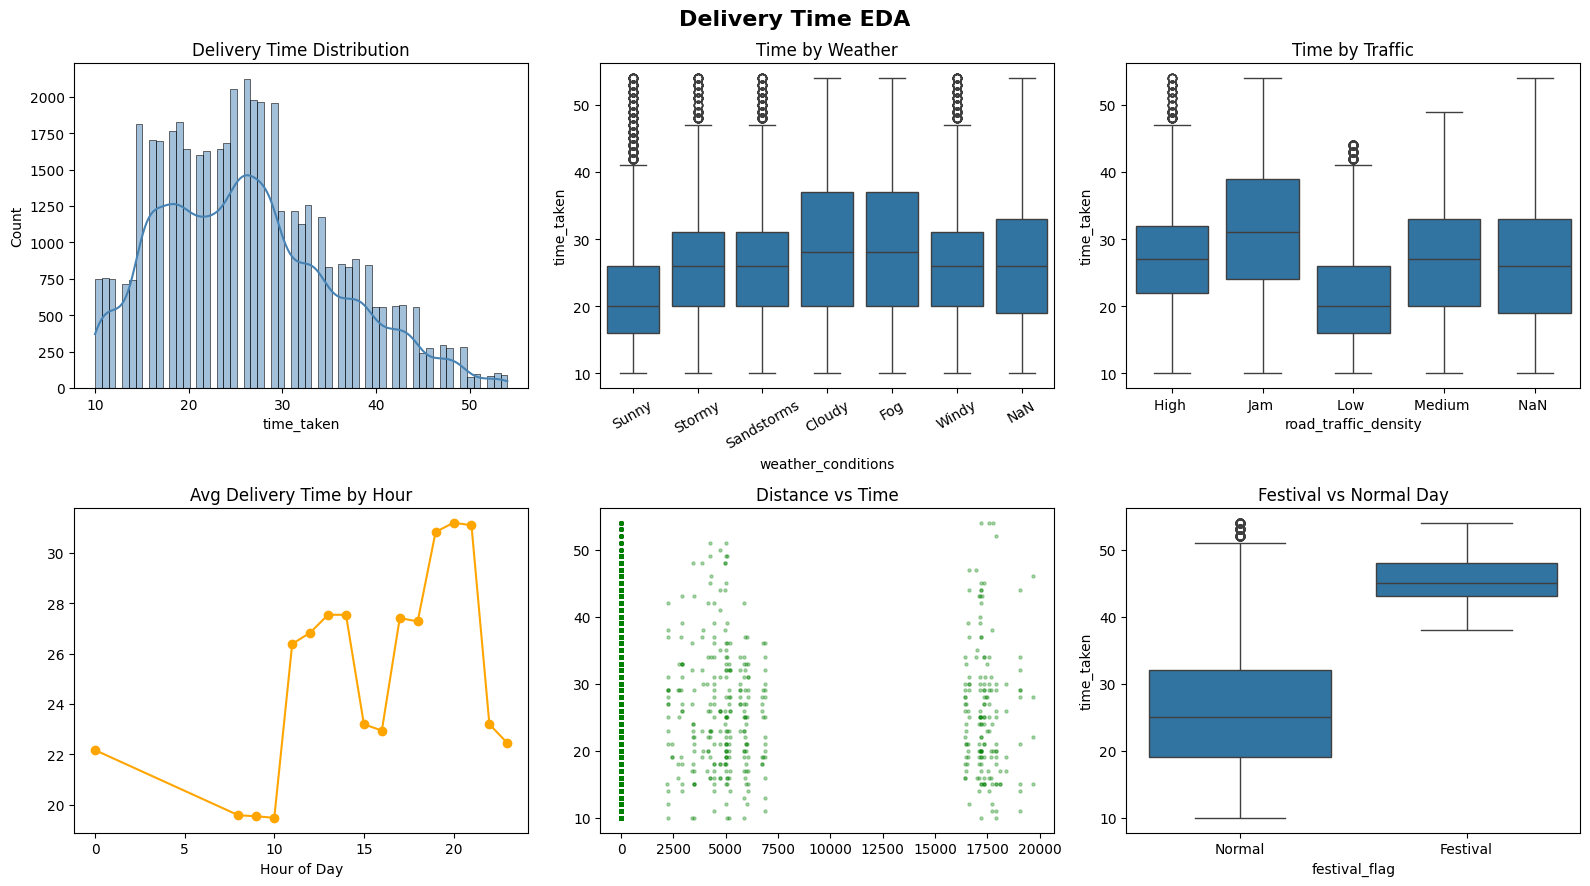

✅ EDA plots saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Delivery Time EDA", fontsize=16, fontweight='bold')

# 1. Target variable
sns.histplot(df['time_taken'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Delivery Time Distribution")

# 2. By weather
sns.boxplot(data=df, x='weather_conditions', y='time_taken', ax=axes[0,1])
axes[0,1].set_title("Time by Weather")
axes[0,1].tick_params(axis='x', rotation=30)

# 3. By traffic
sns.boxplot(data=df, x='road_traffic_density', y='time_taken', ax=axes[0,2])
axes[0,2].set_title("Time by Traffic")

# 4. By hour
hour_avg = df.groupby('order_hour')['time_taken'].mean()
axes[1,0].plot(hour_avg.index, hour_avg.values, marker='o', color='orange')
axes[1,0].set_title("Avg Delivery Time by Hour")
axes[1,0].set_xlabel("Hour of Day")

# 5. Distance vs time
axes[1,1].scatter(df['distance_km'], df['time_taken'], alpha=0.3, color='green', s=5)
axes[1,1].set_title("Distance vs Time")

# 6. Festival vs normal
sns.boxplot(data=df, x='festival_flag', y='time_taken', ax=axes[1,2])
axes[1,2].set_title("Festival vs Normal Day")
axes[1,2].set_xticklabels(['Normal', 'Festival'])

plt.tight_layout()
plt.savefig(f"{PROJECT}/eda_plots.png", dpi=150)
plt.show()
print("✅ EDA plots saved!")

In [ ]:
df.to_csv(f"{PROC}/delivery_clean.csv", index=False)
print(f"✅ Saved! Shape: {df.shape}")
print(f"📁 Location: {PROC}/delivery_clean.csv")

✅ Saved! Shape: (45593, 27)
📁 Location: /content/drive/MyDrive/delivery_delay_project/data/processed/delivery_clean.csv
